# Import and setup

In [1]:
import os

from google.colab import drive
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_poisson_deviance
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [2]:
# Mount google drive
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Group Project/Data/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load Merged Data

**To compare age effects across years fairly,** data was filtered on age 20-80 to compare age effects across years fairly due to data limitation. Age 85 is available from 1999-2005 and age 12-19 is only availabe on 2005-2017. We expect the impact of <20 and 80+ to be immaterial and won't impact our recommendation and conclusion of our analysis.

In [3]:
df_raw = pd.read_csv(os.path.join(base_path, 'merged_df.csv'))
df = df_raw[df_raw.age.between(20, 80)]

# Feature Selection

To remove any weak predictors that may hurt performance

In [4]:
# Renamed the variables to be more descriptive
# Selected features that will have material impact on mortality
# Removed features with multicollinearity
df.rename({
    'BMXBMI': 'BMI',
    'LBXGLU': 'Glucose Level',
    'bpsx_mean': 'Blood Pressure High Band Avg',
    'bpdi_mean': 'Blood Pressure Low Band Avg',
    'LBDLDL': 'LDL Cholesterol Level',
    # 'LBXTR': 'Triglycerides Level',
    'DMDEDUC2_4.0': 'College Undergrad Degree Perc',
    # 'DMDEDUC2_5.0': 'College Graduate Degree Perc',
    'SMQ020_1.0': 'Tried Cigarette Perc',
    'RIDRETH1_3.0': 'White Population Perc',
    # 'LBDTCSI': 'Total Cholesterol Level',
    # 'BMXWAIST': 'Waist Size',
    # 'BMXWT': 'Weight',
    # 'BMXARMC': 'Arm Circumference',
    # 'BMXHT': 'Height',
    # 'RIDRETH1_4.0': 'Black Population Perc',
    }, axis=1, inplace=True)

# Excluding all variables except for the variable renamed above
exclude_cols = [
    "crude_rate_per_100k",
    "SEQN",
    "RIDAGEYR",
    "RIAGENDR",
    "SEQN",
    "SMQ020_1.0",
    "SMQ020_2.0",
    "SMQ020_7.0",
    "SMQ020_9.0",
    'DMDEDUC2_1.0',
    'DMDEDUC2_2.0',
    'DMDEDUC2_3.0',
    'DMDEDUC2_4.0',
    'DMDEDUC2_5.0',
    'DMDEDUC2_7.0',
    'DMDEDUC2_9.0',
    'BPXDI1',
    'BPXDI2',
    'BPXDI3',
    'BPXSY1',
    'BPXSY2',
    'BPXSY3',
    'LBDTCSI',
    'LBDLDL',
    'LBXTR',
    'RIDRETH1_1.0',
    'RIDRETH1_2.0',
    'RIDRETH1_3.0',
    'RIDRETH1_4.0',
    'RIDRETH1_5.0',
    'LBDGLUSI',
    'LBDHDD',
    'LBDHDDSI',
    'LBDLDL',
    'LBDLDLSI',
    'LBDTCSI',
    'LBDTRSI',
    'LBXGH',
    'LBXGLU',
    'LBXTC',
    'LBXTR',
    'BMXARMC',
    'BMXARML',
    'BMXHT',
    'BMXLEG',
    'BMXWAIST',
    'BMXWT',
    'bpdi_mean',
    'bpsx_mean',
    'SMQ020_nan',
    'RIDRETH1_nan',
    'DMDEDUC2_nan',
]

df = df.drop(columns=[c for c in exclude_cols if c in df.columns])

/tmp/ipykernel_90821/3976632172.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename({


In [5]:
# Create morality_rate = deaths / exposure to set as the Y variable.
df['mortality_rate_per_100k'] = (
    df['deaths'] / df['population']
) * 100000


# Supervised Learning

### Model Setup

In [6]:
# 5-Fold CV Setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

target = "mortality_rate_per_100k"

X = df.drop(columns=["deaths", "population", target])
X = sm.add_constant(X)

y = df[target]

## Poisson Regression

Models counts and rate directly where variance is equal to the mean.

In [7]:
poisson_model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson(),
)

results = poisson_model.fit()

print(results.summary())
print("AIC:", results.aic)


                    Generalized Linear Model Regression Results                    
Dep. Variable:     mortality_rate_per_100k   No. Observations:                 1220
Model:                                 GLM   Df Residuals:                     1208
Model Family:                      Poisson   Df Model:                           11
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -9676.8
Date:                     Mon, 29 Jun 2026   Deviance:                       9643.7
Time:                             21:38:32   Pearson chi2:                 1.07e+04
No. Iterations:                          6   Pseudo R-squ. (CS):              1.000
Covariance Type:                 nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

 Calculate Variance Inflation Factor (VIF) to check for Multicollinearity.

In [8]:
vif = pd.DataFrame()
vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif.sort_values("VIF", ascending=False))

                          Feature            VIF
0                           const  195603.943584
1                             age       5.784210
7    Blood Pressure High Band Avg       3.783527
2                          gender       2.207560
6                   Glucose Level       2.136037
11           Tried Cigarette Perc       2.113864
8     Blood Pressure Low Band Avg       1.657468
3                            year       1.582316
5           LDL Cholesterol Level       1.546894
4                             BMI       1.438247
9           White Population Perc       1.398549
10  College Undergrad Degree Perc       1.228228


### 5-Fold CV Model Evaluation

In [9]:
mae_scores = []
rmse_scores = []
r2_scores = []

predicted_all = np.zeros(len(y))

for train_idx, test_idx in cv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = sm.GLM(
        y_train,
        X_train,
        family=sm.families.Poisson()
    ).fit()

    y_pred = model.predict(X_test)

    predicted_all[test_idx] = y_pred

    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_scores.append(r2_score(y_test, y_pred))

print("Poisson Regression (5-Fold CV)")
print(f"MAE  = {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
print(f"RMSE = {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
print(f"R²   = {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")

df["predicted_rate_per_100k_p_5cv"] = predicted_all

Poisson Regression (5-Fold CV)
MAE  = 61.996 ± 5.419
RMSE = 114.259 ± 18.999
R²   = 0.993 ± 0.002


### Dispersion Statistics

This is important to test the poisson assumption that "variance equals the mean" is reasonable for the underlying assumption of E(Y) = Var(Y)

In [10]:
poisson_model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson(),
)

results = poisson_model.fit()
dispersion = results.pearson_chi2 / results.df_resid

print(f"Dispersion Statistic: {dispersion:.3f}")

if dispersion < 0.8:
    print("Possible underdispersion.")
elif dispersion <= 1.5:
    print("Poisson assumption appears reasonable.")
elif dispersion <= 2:
    print("Mild overdispersion detected.")
else:
    print("Substantial overdispersion detected. Consider Negative Binomial regression.")

Dispersion Statistic: 8.853
Substantial overdispersion detected. Consider Negative Binomial regression.


Big overdispersion is detected. Will evaluate negative binomial regression to accommodate wider fluctuations.

## Negative Binomial Regression

In [11]:
nb_model = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial(),
)

nb_results = nb_model.fit()
print(nb_results.summary())
print("AIC:", nb_results.aic)

                    Generalized Linear Model Regression Results                    
Dep. Variable:     mortality_rate_per_100k   No. Observations:                 1220
Model:                                 GLM   Df Residuals:                     1208
Model Family:             NegativeBinomial   Df Model:                           11
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -8701.5
Date:                     Mon, 29 Jun 2026   Deviance:                       23.581
Time:                             21:38:33   Pearson chi2:                     25.1
No. Iterations:                          8   Pseudo R-squ. (CS):             0.8110
Covariance Type:                 nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### 5-Fold CV Model Evaluation

In [12]:
mae_scores = []
rmse_scores = []
r2_scores = []

predictions = np.zeros(len(y))

for train_idx, test_idx in cv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    nb_model = sm.GLM(
        y_train,
        X_train,
        family=sm.families.NegativeBinomial(),
    )

    nb_results = nb_model.fit()
    y_pred = nb_results.predict(
        X_test,
    )

    predictions[test_idx] = y_pred

    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(
        np.sqrt(mean_squared_error(y_test, y_pred))
    )
    r2_scores.append(r2_score(y_test, y_pred))

print("Poisson Regression (5-Fold CV)")
print(f"MAE  = {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
print(f"RMSE = {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
print(f"R²   = {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")

# Store predictions
df["predicted_rate_per_100k_nb_5cv"] = predictions


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha no

Poisson Regression (5-Fold CV)
MAE  = 112.621 ± 13.567
RMSE = 246.741 ± 31.632
R²   = 0.968 ± 0.006


In [13]:
# Need to drop intercept term for Random Forest and KNN models.
X.drop(columns=["const"], inplace=True)


## Random Forest Regressor

Tree-based ensemble. Captures nonlinear effects

Hyperparameter tuning for the Random Forest model was conducted using grid search with five-fold cross-validation. The number of trees (100, 300, 500), maximum tree depth (5, 10, unlimited), and minimum leaf size (1, 3, 5) were evaluated. The optimal model was selected based on the lowest cross-validated RMSE.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 121.19834254954013
MAE: 52.98140391743147
R²: 0.9924843668479167


### Sensitivity Analysis - Tree Depth Sensitivity

In [15]:
depths = [3, 5, 10, 20, None]

for d in depths:
    rf = RandomForestRegressor(
        max_depth=d,
        min_samples_leaf=1,
        random_state=42
    )
    scores = cross_val_score(
        rf,
        X,
        y,
        cv=cv,
        scoring="neg_root_mean_squared_error"
    )
    print(d, -scores.mean())

3 283.74881287148065
5 146.81269072122228
10 120.33496077825605
20 120.42791518079562
None 121.19845882031386


There are minor differences between tree depth 10 to unlimited. We will cap the max depth to 20 to avoid risk of overfitting with unlimited cap.

### Identify Tradeoffs

Deeper trees (Max Dept=None) fit training data better, but excessive depth may create overfitting.

By using more trees (500) it increases model stability and performance with better accuracy but it takes longer training and prediction time.


### Hyperparameter Tuning

In [16]:
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [5, 10, 20],
    "min_samples_leaf": [1, 3, 5]
}

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print(f"Best Parameters:{grid_search.best_params_}")
print(f"\nBest CV RMSE: {-grid_search.best_score_}")

rf_pred = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
mae = mean_absolute_error(y_test, rf_pred)
r2 = r2_score(y_test, rf_pred)

print("\nTest Set Performance")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters:{'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 500}

Best CV RMSE: 141.35740511942575

Test Set Performance
RMSE: 114.66
MAE : 50.81
R²  : 0.9933


In [17]:

best_rf.get_params()


{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 20,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 500,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

### 5-Fold CV Model Evaluation

In [18]:
mae_scores = []
rmse_scores = []
r2_scores = []

predicted_all = np.zeros(len(y))

for train_idx, test_idx in cv.split(X):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    best_rf.fit(X_train, y_train)

    y_pred = best_rf.predict(X_test)

    predicted_all[test_idx] = y_pred

    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_scores.append(r2_score(y_test, y_pred))

df["predicted_rate_per_100k_rf_5cv"] = predicted_all

print("Random Forest (5-Fold CV)")
print(f"MAE  = {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
print(f"RMSE = {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
print(f"R²   = {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")



Random Forest (5-Fold CV)
MAE  = 51.818 ± 4.846
RMSE = 117.823 ± 20.137
R²   = 0.993 ± 0.002


### Ablation Analysis

Understand how much the feature contribute to the model performance by systematically removing one component at a time.

                          Feature     CV RMSE  RMSE Increase
0                             age  605.099796     487.277171
1                          gender  239.012398     121.189773
2                            year  178.427258      60.604633
10           Tried Cigarette Perc  116.587420      -1.235205
9   College Undergrad Degree Perc  116.182617      -1.640008
7     Blood Pressure Low Band Avg  115.817508      -2.005117
6    Blood Pressure High Band Avg  115.639707      -2.182917
5                   Glucose Level  114.834380      -2.988245
4           LDL Cholesterol Level  114.638716      -3.183909
8           White Population Perc  113.900706      -3.921919
3                             BMI  106.756074     -11.066551


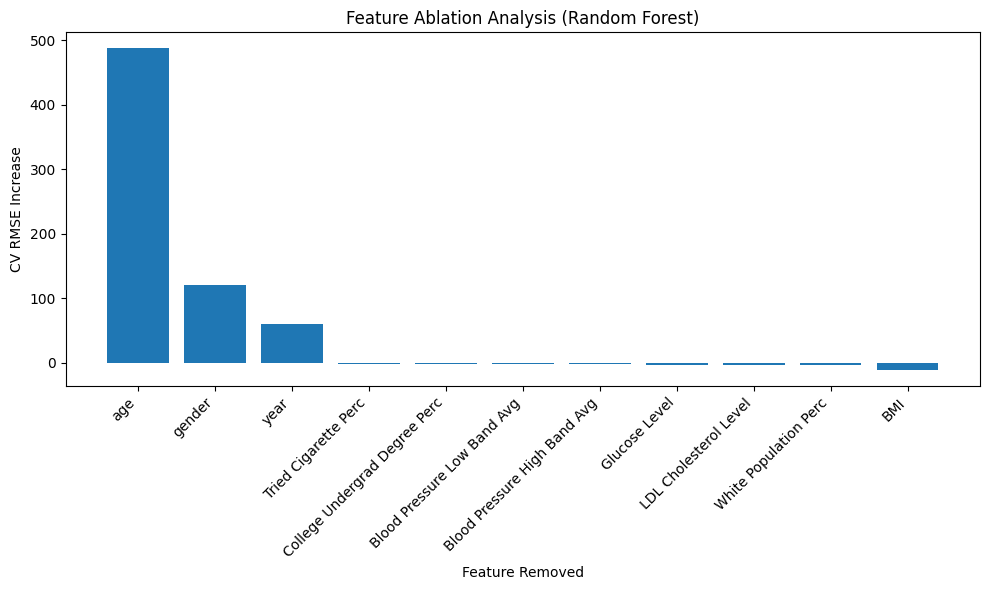

In [19]:
baseline_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

baseline_rmse = -baseline_scores.mean()

results = []

for feature in X.columns:

    X_ablation = X.drop(columns=[feature])

    scores = cross_val_score(
        best_rf,
        X_ablation,
        y,
        cv=cv,
        scoring="neg_root_mean_squared_error"
    )

    ablation_rmse = -scores.mean()

    results.append({
        "Feature": feature,
        "CV RMSE": ablation_rmse,
        "RMSE Increase": ablation_rmse - baseline_rmse
    })

ablation_df = pd.DataFrame(results).sort_values(
    "RMSE Increase",
    ascending=False
)

print(ablation_df)

plt.figure(figsize=(10, 6))
plt.bar(ablation_df["Feature"], ablation_df["RMSE Increase"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("CV RMSE Increase")
plt.xlabel("Feature Removed")
plt.title("Feature Ablation Analysis (Random Forest)")
plt.tight_layout()
plt.show()

### Feature Importance Analysis

                               Mean Importance  Std Importance
age                                   0.929423        0.003751
gender                                0.046397        0.002038
year                                  0.009304        0.000868
Tried Cigarette Perc                  0.004076        0.001509
LDL Cholesterol Level                 0.002827        0.000934
BMI                                   0.001758        0.001475
Blood Pressure High Band Avg          0.001681        0.000228
College Undergrad Degree Perc         0.001370        0.000211
White Population Perc                 0.001237        0.000321
Glucose Level                         0.000981        0.000105
Blood Pressure Low Band Avg           0.000947        0.000084


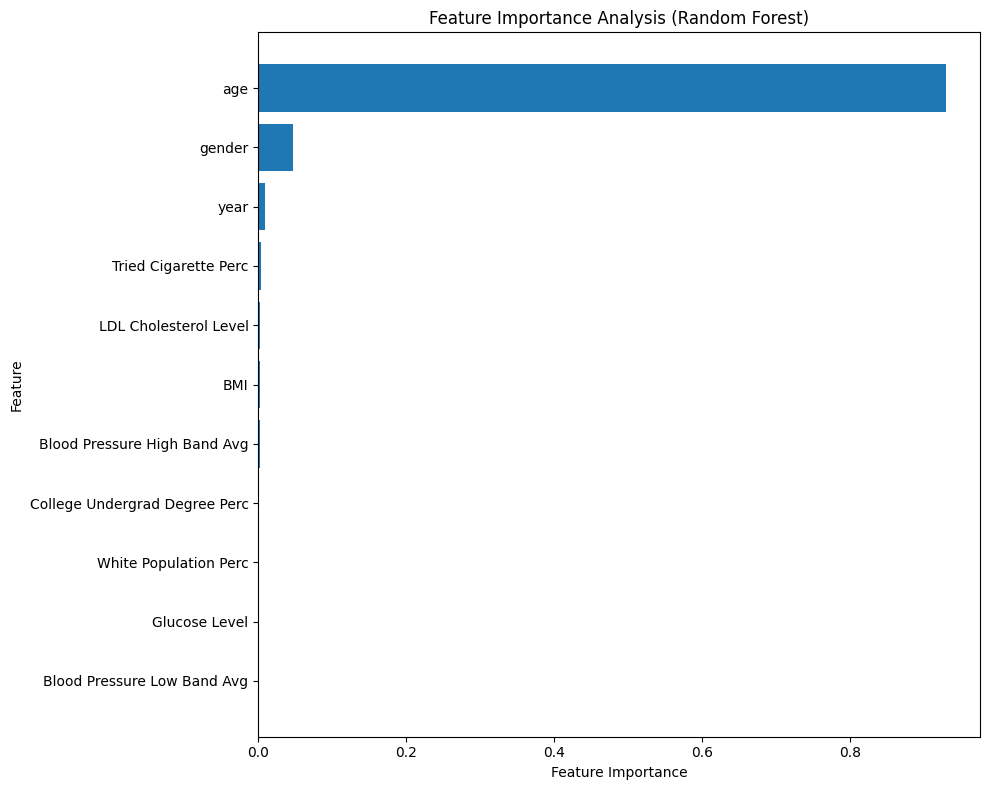

In [20]:
feature_importances = []

for train_idx, test_idx in cv.split(X):

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    best_rf.fit(X_train, y_train)

    feature_importances.append(best_rf.feature_importances_)

importance_df = pd.DataFrame(
    feature_importances,
    columns=X.columns
)

summary_df = pd.DataFrame({
    "Mean Importance": importance_df.mean(),
    "Std Importance": importance_df.std()
})

summary_df = summary_df.sort_values("Mean Importance",ascending=False)

print(summary_df)

summary_df = summary_df.sort_values("Mean Importance",ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(summary_df.index, summary_df["Mean Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance Analysis (Random Forest)")
plt.tight_layout()
plt.show()

### Actual and Predicted Error

In [25]:
df["actual_to_predicted_error_rf_5cv"] = abs(
    df["mortality_rate_per_100k"]
    - df["predicted_rate_per_100k_rf_5cv"]
)

largest_errors = df.sort_values(
    "actual_to_predicted_error_rf_5cv",
    ascending=False
)
print(largest_errors.head(10))

       age  gender  year   deaths  population        BMI  \
645   78.0       1  2017  32364.0    704719.0  27.177778   
655   79.0       1  2017  33103.0    646278.0  25.650000   
644   78.0       1  2015  30740.0    654531.0  27.180000   
647   79.0       1  2001  36322.5    529829.0  26.130000   
646   79.0       1  1999  35604.0    495196.0  28.685000   
624   76.0       1  2015  29755.0    766568.0  27.876923   
650   79.0       1  2007  32918.5    569247.0  26.546667   
1332  79.0       2  1999  36048.0    763787.0  26.772222   
658   80.0       1  2003  35982.0    499679.0  28.052727   
618   76.0       1  2003  32773.5    661551.5  28.275833   

      LDL Cholesterol Level  Glucose Level  Blood Pressure High Band Avg  \
645               98.000000     137.666667                    147.333333   
655               79.500000     123.300000                    133.777778   
644              104.545455     114.818182                    138.500000   
647               97.600000     107

## K-Nearest Neighbors (KNN) Regressors

Instance-based. Distance-based. Makes predictions based on similar observations.


In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(
    n_neighbors=10,
    weights="distance"
)
knn.fit(X_train_scaled,y_train)

pred = knn.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.3f}")

RMSE: 428.92
MAE: 230.24
R²: 0.893


### Hypertuning Parameter

Hyperparameter tuning for KNN focused on the number of neighbors, weighting scheme, and distance metric. Values of K ranging from 3 to 20 were evaluated. Both uniform and distance-weighted voting schemes were considered, along with Manhattan and Euclidean distance metrics. Five-fold cross-validation was used to identify the parameter combination that minimized RMSE.

In [27]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor())
])

param_grid = {
    "knn__n_neighbors": range(3, 21),
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]  # Manhattan and Minkowski
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

best_knn = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV RMSE:")
print(-grid_search.best_score_)

knn_pred = best_knn.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
mae = mean_absolute_error(y_test, knn_pred)
r2 = r2_score(y_test, knn_pred)

print("\nTest Set Performance")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters:
{'knn__n_neighbors': 15, 'knn__p': 1, 'knn__weights': 'distance'}

Best CV RMSE:
506.38258264229216

Test Set Performance
RMSE: 422.94
MAE : 214.43
R²  : 0.8958


### 5-Fold CV Model Evaluation



In [28]:
mae_scores = []
rmse_scores = []
r2_scores = []

predicted_all = np.zeros(len(y))

for train_idx, test_idx in cv.split(X):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)


    knn = KNeighborsRegressor(n_neighbors=5, weights="distance", p=1)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    predicted_all[test_idx] = y_pred

    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_scores.append(r2_score(y_test, y_pred))

df["predicted_rate_per_100k_knn_5cv"] = predicted_all

print("KNN (5-Fold CV)")
print(f"MAE  = {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
print(f"RMSE = {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
print(f"R²   = {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")

KNN (5-Fold CV)
MAE  = 239.578 ± 30.308
RMSE = 481.353 ± 84.652
R²   = 0.878 ± 0.038


## Model Prections Summary

In [30]:
df

,age,gender,year,deaths,population,BMI,LDL Cholesterol Level,Glucose Level,Blood Pressure High Band Avg,Blood Pressure Low Band Avg,White Population Perc,College Undergrad Degree Perc,Tried Cigarette Perc,mortality_rate_per_100k,predicted_rate_per_100k_p_5cv,predicted_rate_per_100k_nb_5cv,predicted_rate_per_100k_rf_5cv,actual_to_predicted_error_rf_5cv,predicted_rate_per_100k_knn_5cv
56,20.0,1,1999,2616.0,2010201.0,24.504286,114.857143,88.114286,119.119048,69.976190,0.357143,0.428571,0.357143,130.136240,66.586103,88.576804,128.149365,1.986875,134.588729
57,20.0,1,2001,2834.5,2096772.0,23.904737,93.444444,93.452632,117.666667,66.017544,0.210526,0.263158,0.473684,135.183988,65.508483,91.338570,135.621508,0.437521,141.122296
58,20.0,1,2003,2956.5,2143257.0,25.559200,91.391304,93.161538,117.500000,61.243590,0.500000,0.307692,0.346154,137.944260,66.596008,99.171979,125.680180,12.264079,143.409221
59,20.0,1,2005,2881.5,2159269.0,25.002632,96.058824,95.578947,114.192982,60.789474,0.578947,0.368421,0.473684,133.447940,63.393801,93.042183,137.734204,4.286264,143.865232
60,20.0,1,2007,2976.0,2180082.0,23.497500,87.578947,100.210526,116.466667,66.733333,0.450000,0.300000,0.500000,136.508627,59.216977,86.724187,132.933488,3.575138,142.884324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1347,80.0,2,2009,33109.0,753585.0,26.305377,109.697917,110.206186,137.391586,57.035599,0.768519,0.314815,0.231481,4393.532249,4248.734753,4173.878876,4140.967251,252.564998,3898.806614
1348,80.0,2,2011,32260.0,757789.0,26.258333,118.476923,116.253731,143.214286,64.138095,0.729730,0.229730,0.337838,4257.121705,3962.001962,3818.957744,4448.063948,190.942242,3437.069629
1349,80.0,2,2013,31284.5,738501.5,27.368293,108.532468,109.506173,140.075949,57.308017,0.705882,0.211765,0.352941,4236.213467,3935.342406,4025.800439,4395.441281,159.227814,4167.859047
1350,80.0,2,2015,31321.5,748498.0,27.517045,98.263889,119.952381,143.822222,62.866667,0.600000,0.244444,0.233333,4184.580320,3806.300531,3953.088585,4209.708088,25.127768,3628.668728
